## 1. Business Understanding

 We need to establish a delivery network using drones to serve a specific client base.


## 2. Data Understanding

We first load the data and inspect its structure.


In [9]:
import pandas as pd
from sklearn.cluster import KMeans

df = pd.read_csv('datasets/drone_cust_locations.csv', sep=';', na_values='NaN')

df.head()


,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


## 3. Data Preparation

## 4. Modeling

We randomly choose three depot points and visualize them.

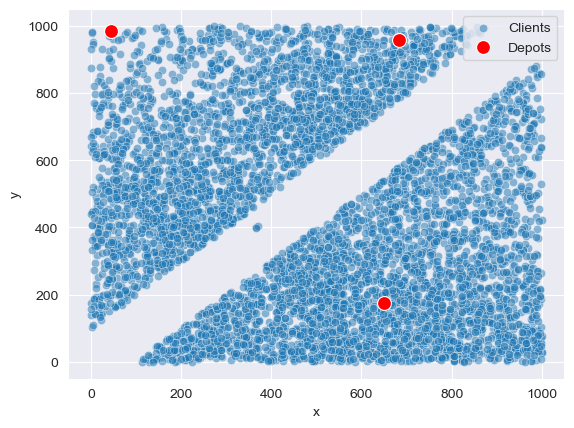

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

seed = 55
n_depots = 3
random_points = df.sample(n=n_depots, random_state=seed)

sns.scatterplot(data=df, x="x", y="y", alpha=0.5, label="Clients")
sns.scatterplot(data=random_points, x="x", y="y", color="red", s=100, label="Depots")

plt.legend()
plt.show()

We use the K-Means algorithm to partition clients into service areas based on proximity. The algorithm mathematically calculates a centroid for each cluster, which serves as the exact, optimal location for a drone depot. 

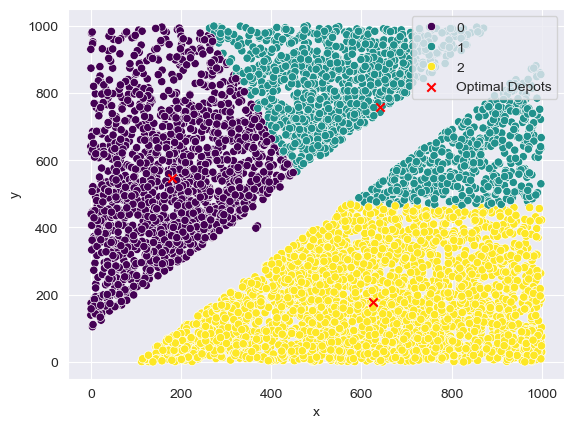

In [11]:
initial_centers = random_points[['x', 'y']].values

model = KMeans(n_clusters=n_depots, init=initial_centers, n_init=1, random_state=seed)
df['cluster'] = model.fit_predict(df[['x', 'y']])

optimal_depots = model.cluster_centers_

sns.scatterplot(data=df, x="x", y="y", hue="cluster", palette="viridis")
plt.scatter(optimal_depots[:, 0], optimal_depots[:, 1], c='red', marker='x', label="Optimal Depots")
plt.legend()
plt.show()

Now we try with 10 depots. Every area is colored accordingly. We did not notice any significant difference in computation time.

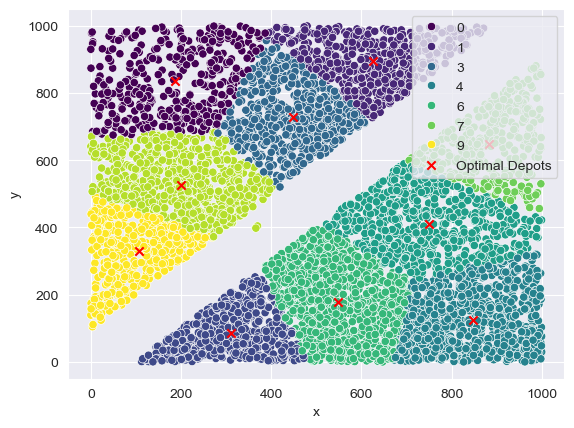

In [12]:
n_depots = 10
random_points = df.sample(n=n_depots, random_state=seed)
initial_centers = random_points[['x', 'y']].values

model = KMeans(n_clusters=n_depots, init=initial_centers, n_init=1, random_state=seed)
df['cluster'] = model.fit_predict(df[['x', 'y']])

optimal_depots = model.cluster_centers_

sns.scatterplot(data=df, x="x", y="y", hue="cluster", palette="viridis")
plt.scatter(optimal_depots[:, 0], optimal_depots[:, 1], c='red', marker='x', label="Optimal Depots")
plt.legend()
plt.show()

### Agglomerative hierarchical clustering

Next, we implemented agglomerative hierarchical clustering to compare its performance against K-means. Visually the cluster formations in the lower region of the plot remained relatively stable, but the depot locations in the upper region experienced noticeable shifts.

The computational overhead increased significantly, with execution time rising from 0.6 seconds to 1.5 seconds.

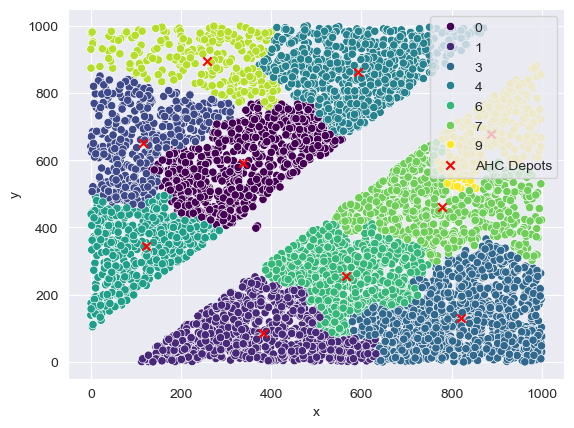

In [13]:
from sklearn.cluster import AgglomerativeClustering

hc_model = AgglomerativeClustering(n_clusters=n_depots)
df['closest_depot'] = hc_model.fit_predict(df[['x', 'y']])

# Calculating depot locations
optimal_depots = df.groupby('closest_depot')[['x', 'y']].mean().values

sns.scatterplot(data=df, x="x", y="y", hue="closest_depot", palette="viridis")
plt.scatter(optimal_depots[:, 0], optimal_depots[:, 1], c='red', marker='x', label="AHC Depots")
plt.legend()
plt.show()

## 5. Evaluation

To compare the clustering algorithms, we calculated the silhouette score for both models using 10 depots.

    K-Means: 0.368

    AHC: 0.341

K-Means achieved a slightly higher score, indicating it created more cohesive and distinct service areas. Scores in the 0.35 range suggest continuous geographic distribution with some boundary overlap, which is expected in a realistic client landscape. Because K-Means produced superior cluster separations and executed significantly faster (0.6s vs 1.5s), it is the optimal algorithm for this drone logistics network.

In [14]:
from sklearn.metrics import silhouette_score

# K-Means
kmeans_labels = model.fit_predict(df[['x', 'y']])
kmeans_silhouette = silhouette_score(df[['x', 'y']], kmeans_labels)

# AHC
ahc_labels = hc_model.fit_predict(df[['x', 'y']])
ahc_silhouette = silhouette_score(df[['x', 'y']], ahc_labels)

print(f"K-Means Silhouette Score: {kmeans_silhouette:.3f}")
print(f"AHC Silhouette Score: {ahc_silhouette:.3f}")


K-Means Silhouette Score: 0.368
AHC Silhouette Score: 0.341


To find the optimal amount of depots, we use the elbow method. K-means model shows that 3-4 depots are the perfect amount for the task.

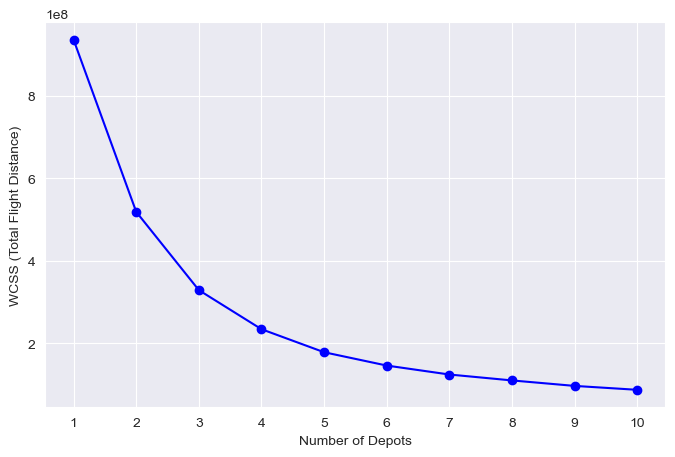

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    model = KMeans(init='random', n_clusters=i, n_init=10, random_state=42)
    model.fit(df[['x', 'y']]) 
    wcss.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Depots')
plt.ylabel('WCSS (Total Flight Distance)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# 6. Deployment



### Depot Placement Strategy

Based on the Elbow Method (WCSS) and Silhouette Scores, there is a point of diminishing returns. Adding too many depots eventually provides minimal reduction in drone flight distances while drastically increasing infrastructure costs. The business should select the number of depots at the "elbow" of the inertia curve to balance flight efficiency with setup costs.


### Algorithm Comparison

K-Means proves more practical and efficient for this logistics network than AHC. It automatically calculates the exact optimal depot coordinates and generates clean, linear service boundaries, whereas AHC requires manual center computation and often produces irregular, organic zones. Additionally, K-Means is significantly faster and more scalable—executing in 0.6 seconds compared to AHC's 1.5 seconds—because AHC's requirement to calculate every pairwise client distance makes it computationally expensive for larger datasets.